# My Level 1 Heading

In [1]:
import ibis
from ibis import _
ibis.options.interactive = True
con = ibis.duckdb.connect(':memory:')

In [2]:
# Ibis doesn't attempt to provide plot methods on dataframes like Pandas does, so I've chosen to use plotnine for plotting, but you could use any plotting library you like.
import plotnine as p9
from matplotlib.ticker import MaxNLocator
import shutil

Note: When I copied the required CSV files from the tutorial into this repo, I compressed them with zstd: i.e. zstd -19 311-service-requests.csv -o 311-service-requests.csv.zst

## Chapter 1: Reading from a CSV

The CSV dataset (bikes.csv) that the tutorial reads in is about cyclists in Montréal. The original data is available [here](https://donnees.montreal.ca/ville-de-montreal/cyclistes-sur-les-pistes-cyclables). The dataset is a list of how many people were on 7 different bike paths in Montreal, each day.

In [3]:
bikes = con.read_csv('./data/bikes.csv.zst', delim=';', encoding='latin-1', null_padding=True, auto_detect=True, strict_mode=False, )
bikes.head(3)

# Original Pandas Tutorial Code:
# df = pd.read_csv('./data/bikes.csv', sep=';', encoding='latin1', parse_dates=['Date'], dayfirst=True, index_col='Date')
# df[:3]

┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Date       ┃ Berri 1 ┃ Brébeuf (données non disponibles) ┃ Côte-Sainte-Catherine ┃ Maisonneuve 1 ┃ Maisonneuve 2 ┃ du Parc ┃ Pierre-Dupuy ┃ Rachel1 ┃ St-Urbain (données non disponibles) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ date       │ int64   │ string                            │ int64                 │ int64         │ int64         │ int64   │ int64        │ int64   │ string                              │
├────────────┼─────────┼───────────────────────────────────┼───────────────────────┼───────────────┼───────────────┼─────────┼──────────────┼─────────┼─────────────────────────────────────┤
│ 2012-01-01 │      35 │ NULL                              │                     0 │            38 │            51 │      26 │           10 │      16 │ NULL                                │
│ 2012-01-02 │      83 │ NULL                              │                     1 │            68 │           153 │      53 │            6 │      43 │ NULL                                │
│ 2012-01-03 │     135 │ NULL                              │                     2 │           104 │           248 │      89 │            3 │      58 │ NULL                                │
└────────────┴─────────┴───────────────────────────────────┴───────────────────────┴───────────────┴───────────────┴─────────┴──────────────┴─────────┴─────────────────────────────────────┘

The tutorial also demonstrates how to select a single column from the dataframe.

In [4]:
bikes.select('Berri 1')

# Original Pandas Tutorial Code:
# df['Berri 1']

┏━━━━━━━━━┓
┃ Berri 1 ┃
┡━━━━━━━━━┩
│ int64   │
├─────────┤
│      35 │
│      83 │
│     135 │
│     144 │
│     197 │
│     146 │
│      98 │
│      95 │
│     244 │
│     397 │
│       … │
└─────────┘

Then plot that column:

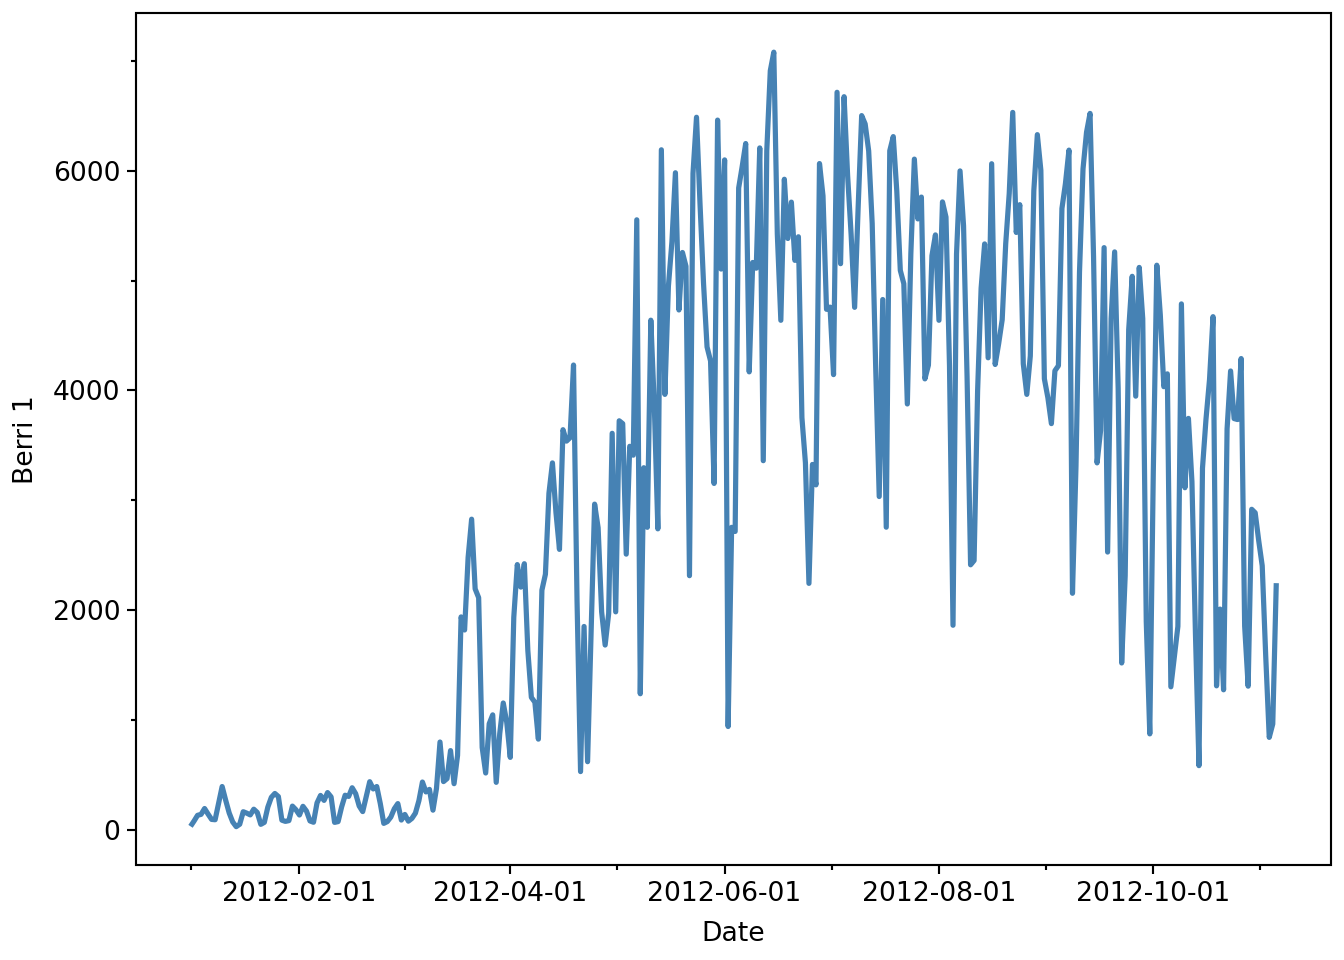

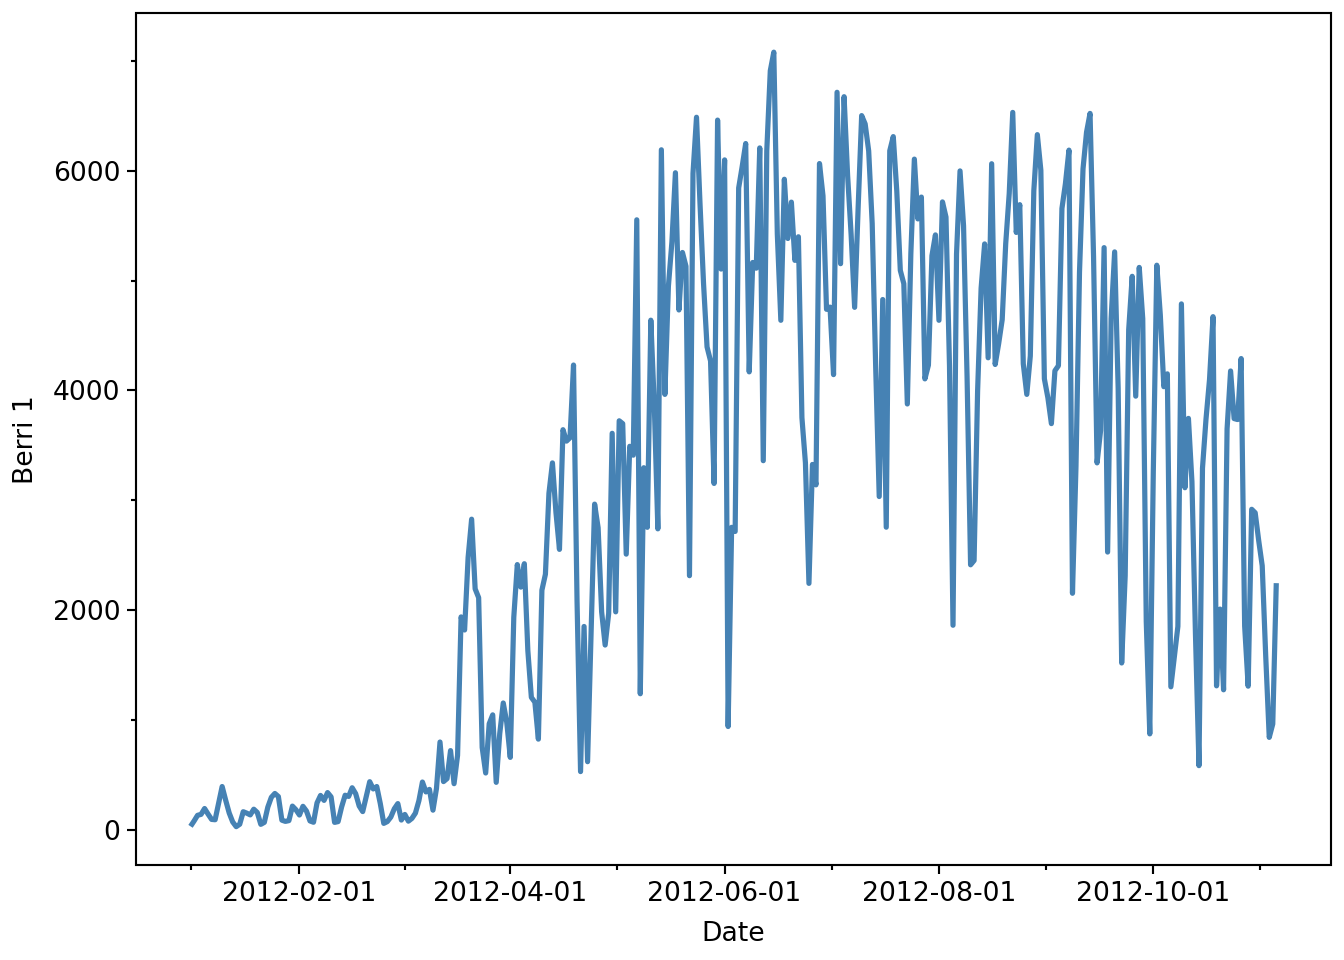

In [5]:
p9.ggplot(bikes.select('Date', 'Berri 1'), p9.aes("Date", "Berri 1")) + \
    p9.geom_line(color='steelblue', size=1.1) + \
    p9.theme_matplotlib()

# Original Pandas Tutorial Code:
# df['Berri 1'].plot()

## Chapter 2: Selecting data & finding the most common complaint type

This section of the tutorial uses a new dataset, which is a subset of the 311 service requests from [NYC Open Data](https://nycopendata.socrata.com/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9).

In [6]:
complaints = con.read_csv('./data/311-service-requests.csv.zst')
# For tidyness, let's get rid of the spaces in column names:
# rename_dict = {col: col.replace(" ", "_") for col in complaints.columns if " " in col}
rename_dict = {col.replace(" ", "_"): col for col in complaints.columns if " " in col}
complaints = complaints.rename(rename_dict)

complaints

# Original Pandas Tutorial Code:
# complaints = pd.read_csv('./data/311-service-requests.csv', dtype='unicode')

┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Unique_Key ┃ Created_Date        ┃ Closed_Date         ┃ Agency ┃ Agency_Name                             ┃ Complaint_Type          ┃ Descriptor                   ┃ Location_Type       ┃ Incident_Zip ┃ Incident_Address          ┃ Street_Name        ┃ Cross_Street_1  ┃ Cross_Street_2                   ┃ Intersection_Street_1 ┃ Intersection_Street_2 ┃ Address_Type ┃ City                ┃ Landmark ┃ Facility_Type ┃ Status   ┃ Due_Date            ┃ Resolution_Action_Updated_Date ┃ Community_Board ┃ Borough   ┃ X_Coordinate_(State_Plane) ┃ Y_Coordinate_(State_Plane) ┃ Park_Facility_Name ┃ Park_Borough ┃ School_Name ┃ School_Number ┃ School_Region ┃ School_Code ┃ School_Phone_Number ┃ School_Address ┃ School_City ┃ School_State ┃ School_Zip  ┃ School_Not_Found ┃ School_or_Citywide_Complaint ┃ Vehicle_Type ┃ Taxi_Company_Borough ┃ Taxi_Pick_Up_Location ┃ Bridge_Highway_Name ┃ Bridge_Highway_Direction ┃ Road_Ramp ┃ Bridge_Highway_Segment ┃ Garage_Lot_Name ┃ Ferry_Direction ┃ Ferry_Terminal_Name ┃ Latitude  ┃ Longitude  ┃ Location                                 ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ int64      │ timestamp(6)        │ timestamp(6)        │ string │ string                                  │ string                  │ string                       │ string              │ string       │ string                    │ string             │ string          │ string                           │ string                │ string                │ string       │ string              │ string   │ string        │ string   │ timestamp(6)        │ timestamp(6)                   │ string          │ string    │ int64                      │ int64                      │ string             │ string       │ string      │ string        │ string        │ string      │ string              │ string         │ string      │ string       │ string      │ string           │ string   

Selecting this first 5 rows of the 'Complaint Type' column:

In [7]:
complaints.select('Complaint_Type').head(5)

# Original Pandas Tutorial Code:
# complaints['Complaint Type'][:5]

┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Complaint_Type          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ string                  │
├─────────────────────────┤
│ Noise - Street/Sidewalk │
│ Illegal Parking         │
│ Noise - Commercial      │
│ Noise - Vehicle         │
│ Rodent                  │
└─────────────────────────┘

Selecting the first 10 rows of two columns:

In [8]:
complaints.select('Complaint_Type', 'Borough').head(10)

# Original Pandas Tutorial Code:
# complaints[['Complaint Type', 'Borough']][:10]

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Complaint_Type          ┃ Borough   ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ string                  │ string    │
├─────────────────────────┼───────────┤
│ Noise - Street/Sidewalk │ QUEENS    │
│ Illegal Parking         │ QUEENS    │
│ Noise - Commercial      │ MANHATTAN │
│ Noise - Vehicle         │ MANHATTAN │
│ Rodent                  │ MANHATTAN │
│ Noise - Commercial      │ QUEENS    │
│ Blocked Driveway        │ QUEENS    │
│ Noise - Commercial      │ QUEENS    │
│ Noise - Commercial      │ MANHATTAN │
│ Noise - Commercial      │ BROOKLYN  │
└─────────────────────────┴───────────┘

Determining the most common complaint type:

In [9]:
complaint_counts = complaints.group_by('Complaint_Type').aggregate(n=_.count()).order_by(ibis.desc('n'))
complaint_counts

# Notes:
#   .count() is a method of a table expression, not a general function in the ibis library.
#   So you could call it like this: complaints.group_by('Complaint Type').count()
#   But if you want the opption to calculate several aggregation columns (and control the
#   names of the resultant columns), you will probably want to use .aggregate().
#   But then, to use the .count() method, you will need to call it via Ibis's
#   deferred expression API (i.e. ibis._), which is just a way to reference the table expresion
#   from the previous step in the method chain (and lets us call the .count() method of the 
#   previous step).

# Original Pandas Tutorial Code:
# complaint_counts = complaints['Complaint Type'].value_counts()
# complaint_counts

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Complaint_Type         ┃ n     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ string                 │ int64 │
├────────────────────────┼───────┤
│ HEATING                │ 14200 │
│ GENERAL CONSTRUCTION   │  7471 │
│ Street Light Condition │  7117 │
│ DOF Literature Request │  5797 │
│ PLUMBING               │  5373 │
│ PAINT - PLASTER        │  5149 │
│ Blocked Driveway       │  4590 │
│ NONCONST               │  3998 │
│ Street Condition       │  3473 │
│ Illegal Parking        │  3343 │
│ …                      │     … │
└────────────────────────┴───────┘

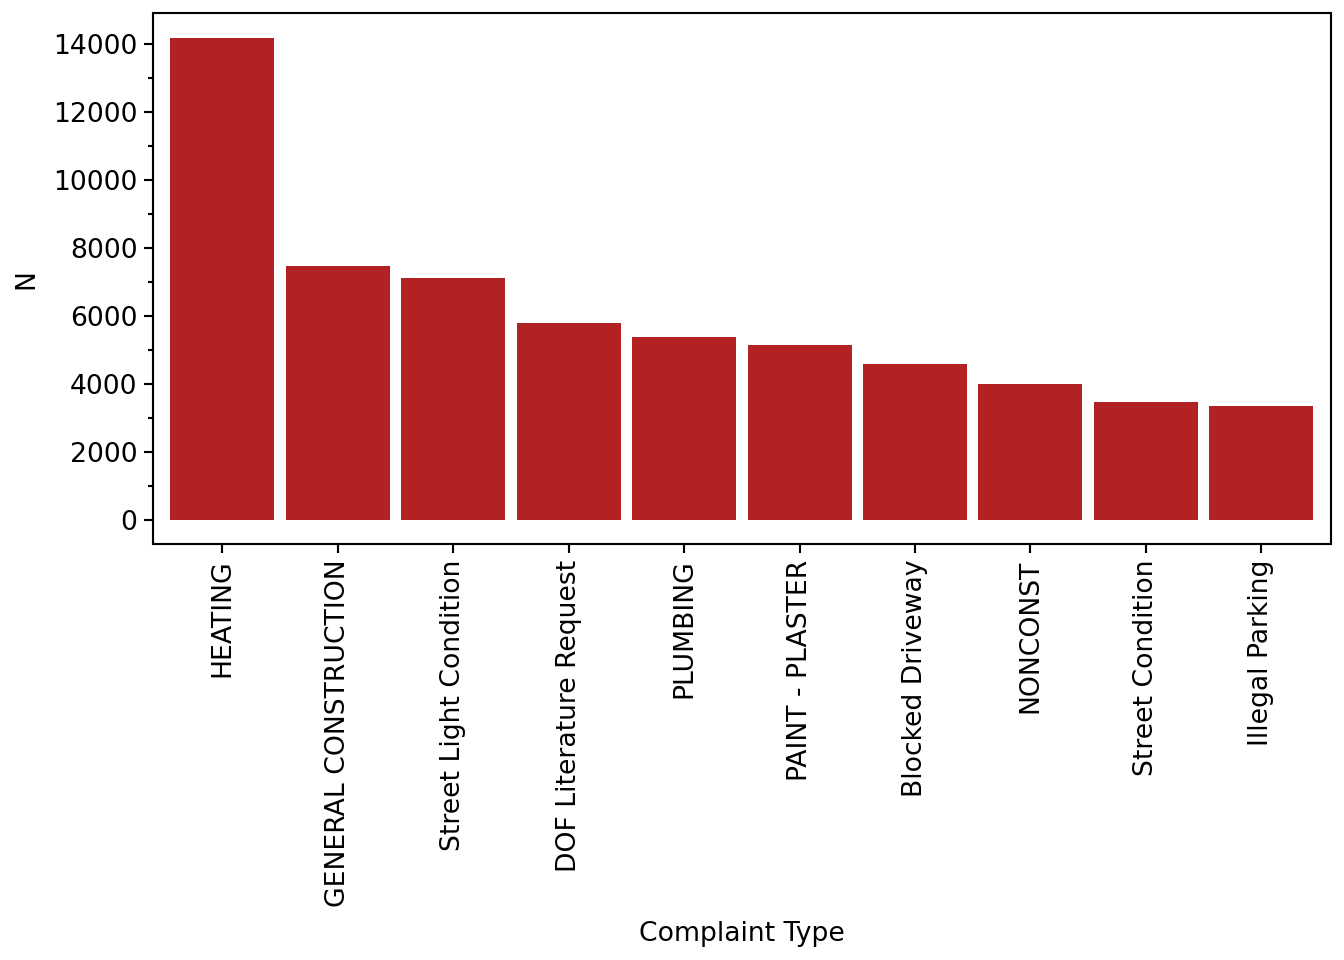

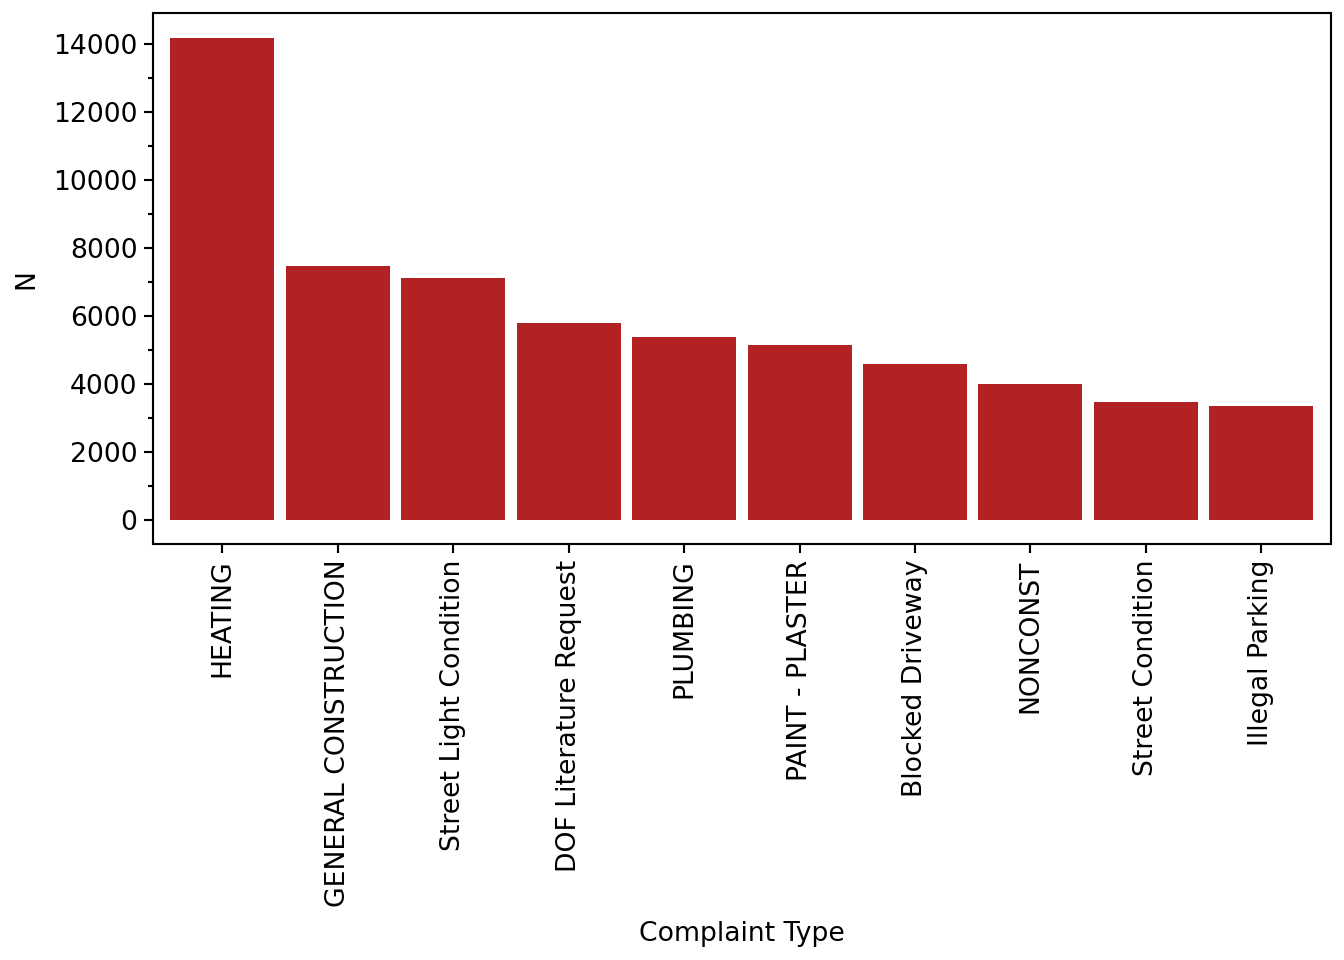

In [10]:
(   p9.ggplot(complaint_counts.head(10), p9.aes(x="reorder(Complaint_Type, n, ascending=False)", y="n")) +
    p9.geom_col(fill='firebrick') +
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits)) +
    p9.labs(x="Complaint Type", y="N") +
    p9.theme_matplotlib() +
    p9.theme(axis_text_x=p9.element_text(angle=90))
)

# Original Pandas Tutorial Code:
# complaint_counts[:10].plot(kind='bar')

## Chapter 3 - Which borough has the most noise complaints

Having a look at noise complaints in Brooklyn:

In [11]:
noise_complaints = complaints.filter((_.Complaint_Type == "Noise - Street/Sidewalk") & (_.Borough == "BROOKLYN")).head(5)

# Original Pandas Tutorial Code:
# is_noise = complaints['Complaint Type'] == "Noise - Street/Sidewalk"
# in_brooklyn = complaints['Borough'] == "BROOKLYN"
# complaints[is_noise & in_brooklyn][:5]

Looking at which Burough has the most noise complaints:

In [12]:
noise_complaints = (
    complaints
    .filter(_.Complaint_Type == "Noise - Street/Sidewalk")
    .group_by('Borough')
    .aggregate(n=_.count())
    .order_by(ibis.desc('n'))
)

noise_complaints

# Original Pandas Tutorial Code:
# is_noise = complaints['Complaint Type'] == "Noise - Street/Sidewalk"
# noise_complaints = complaints[is_noise]
# noise_complaints['Borough'].value_counts()

┏━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Borough       ┃ n     ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━┩
│ string        │ int64 │
├───────────────┼───────┤
│ MANHATTAN     │   917 │
│ BROOKLYN      │   456 │
│ BRONX         │   292 │
│ QUEENS        │   226 │
│ STATEN ISLAND │    36 │
│ Unspecified   │     1 │
└───────────────┴───────┘

Dividing the number of noise complaints by the total number of complaints:

┏━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┓
┃ Borough       ┃ n     ┃ n_perc   ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━┩
│ string        │ int64 │ float64  │
├───────────────┼───────┼──────────┤
│ BRONX         │   292 │ 0.014833 │
│ BROOKLYN      │   456 │ 0.013864 │
│ MANHATTAN     │   917 │ 0.037755 │
│ QUEENS        │   226 │ 0.010143 │
│ STATEN ISLAND │    36 │ 0.007474 │
│ Unspecified   │     1 │ 0.000141 │
└───────────────┴───────┴──────────┘


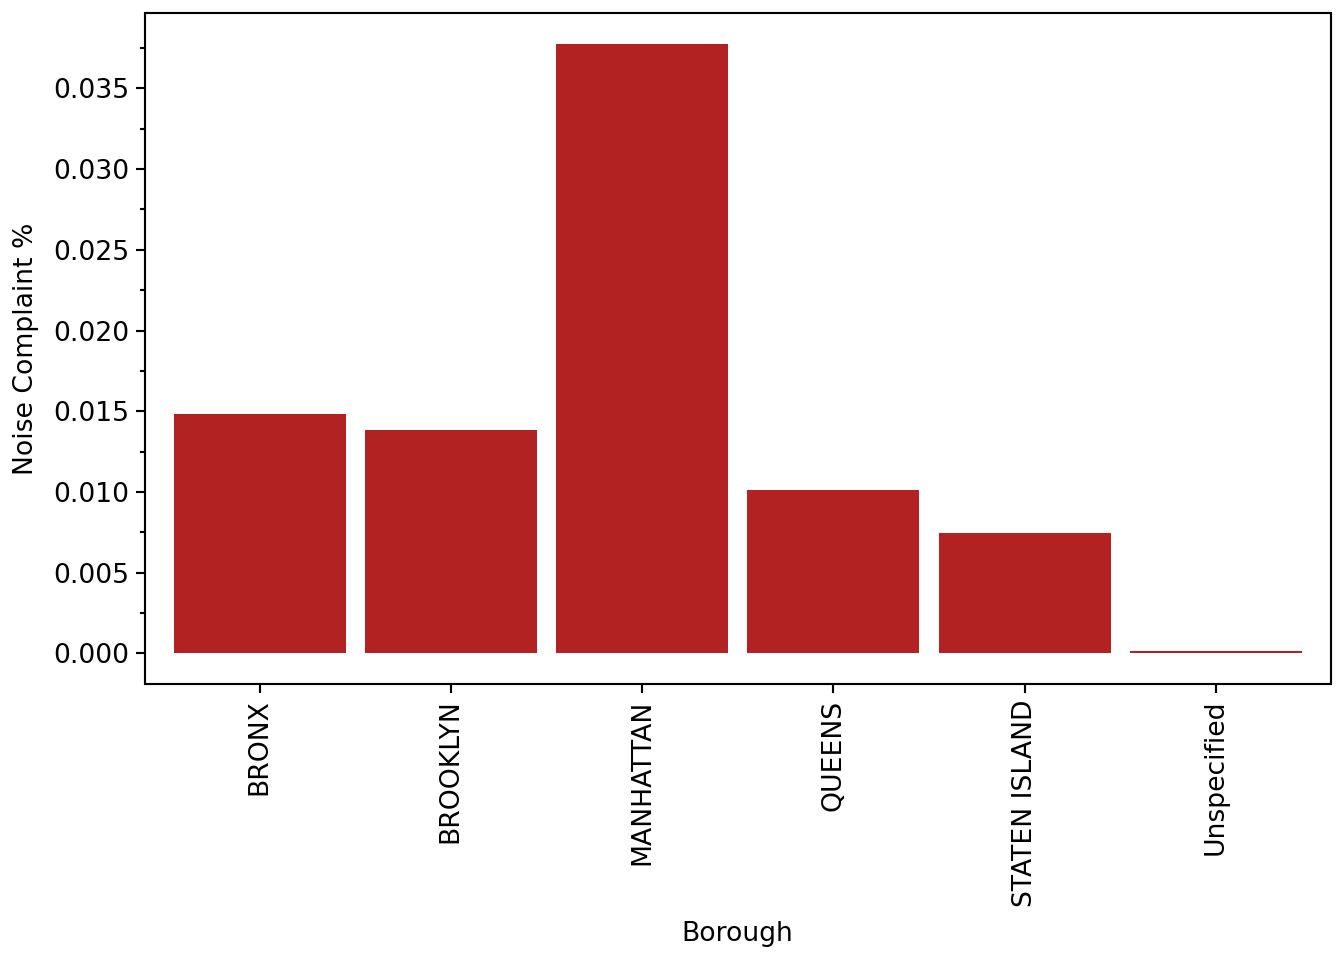

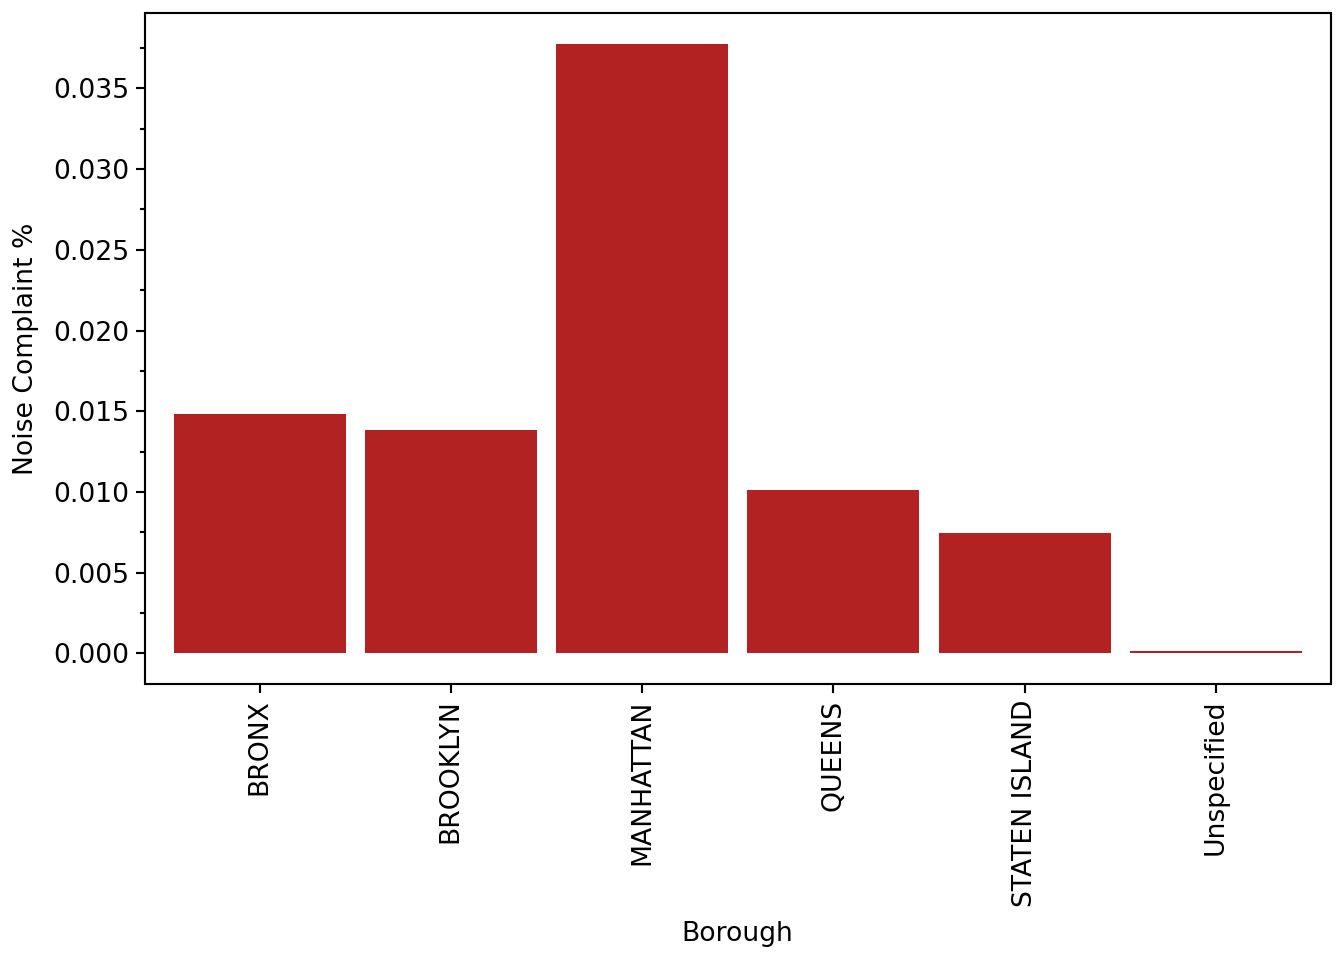

In [13]:
noise_complaints = (
    complaints
    .group_by('Borough')
    .aggregate(
        n=_.count(where = _.Complaint_Type == "Noise - Street/Sidewalk"),
        n_perc=_.count(where =_.Complaint_Type == "Noise - Street/Sidewalk") / _.count(),
    ) \
    .order_by('Borough')
)

print(noise_complaints)

p9.ggplot(noise_complaints, p9.aes(x="Borough", y="n_perc")) + \
    p9.geom_col(fill='firebrick') + \
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits)) + \
    p9.labs(y="Noise Complaint %") + \
    p9.theme_matplotlib() + \
    p9.theme(axis_text_x=p9.element_text(angle=90))

# Original Pandas Tutorial Code:
# noise_complaint_counts = noise_complaints['Borough'].value_counts()
# complaint_counts = complaints['Borough'].value_counts()
# (noise_complaint_counts / complaint_counts.astype(float)).plot(kind='bar')

## Chapter 4 - Find out on which weekday people bike the most with groupby and aggregate

Adding a 'weekday' column to the cycling dataframe:

In [14]:
berri_bikes = (
    bikes
    .select('Date', 'Berri 1')
    .mutate(
        weekday = _.Date.day_of_week.index()
    )
)

berri_bikes.head(5)

# Original Pandas Tutorial Code:
# berri_bikes = bikes[['Berri 1']].copy()
# berri_bikes['weekday'] = berri_bikes.index.weekday
# berri_bikes[:5]

┏━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┓
┃ Date       ┃ Berri 1 ┃ weekday ┃
┡━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━┩
│ date       │ int64   │ int16   │
├────────────┼─────────┼─────────┤
│ 2012-01-01 │      35 │       6 │
│ 2012-01-02 │      83 │       0 │
│ 2012-01-03 │     135 │       1 │
│ 2012-01-04 │     144 │       2 │
│ 2012-01-05 │     197 │       3 │
└────────────┴─────────┴─────────┘

Adding up the cyclists by weekday:

┏━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ weekday ┃ cyclist_count ┃ weekday_name ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ int16   │ int64         │ string       │
├─────────┼───────────────┼──────────────┤
│       0 │        134298 │ Monday       │
│       1 │        135305 │ Tuesday      │
│       2 │        152972 │ Wednesday    │
│       3 │        160131 │ Thursday     │
│       4 │        141771 │ Friday       │
│       5 │        101578 │ Saturday     │
│       6 │         99310 │ Sunday       │
└─────────┴───────────────┴──────────────┘


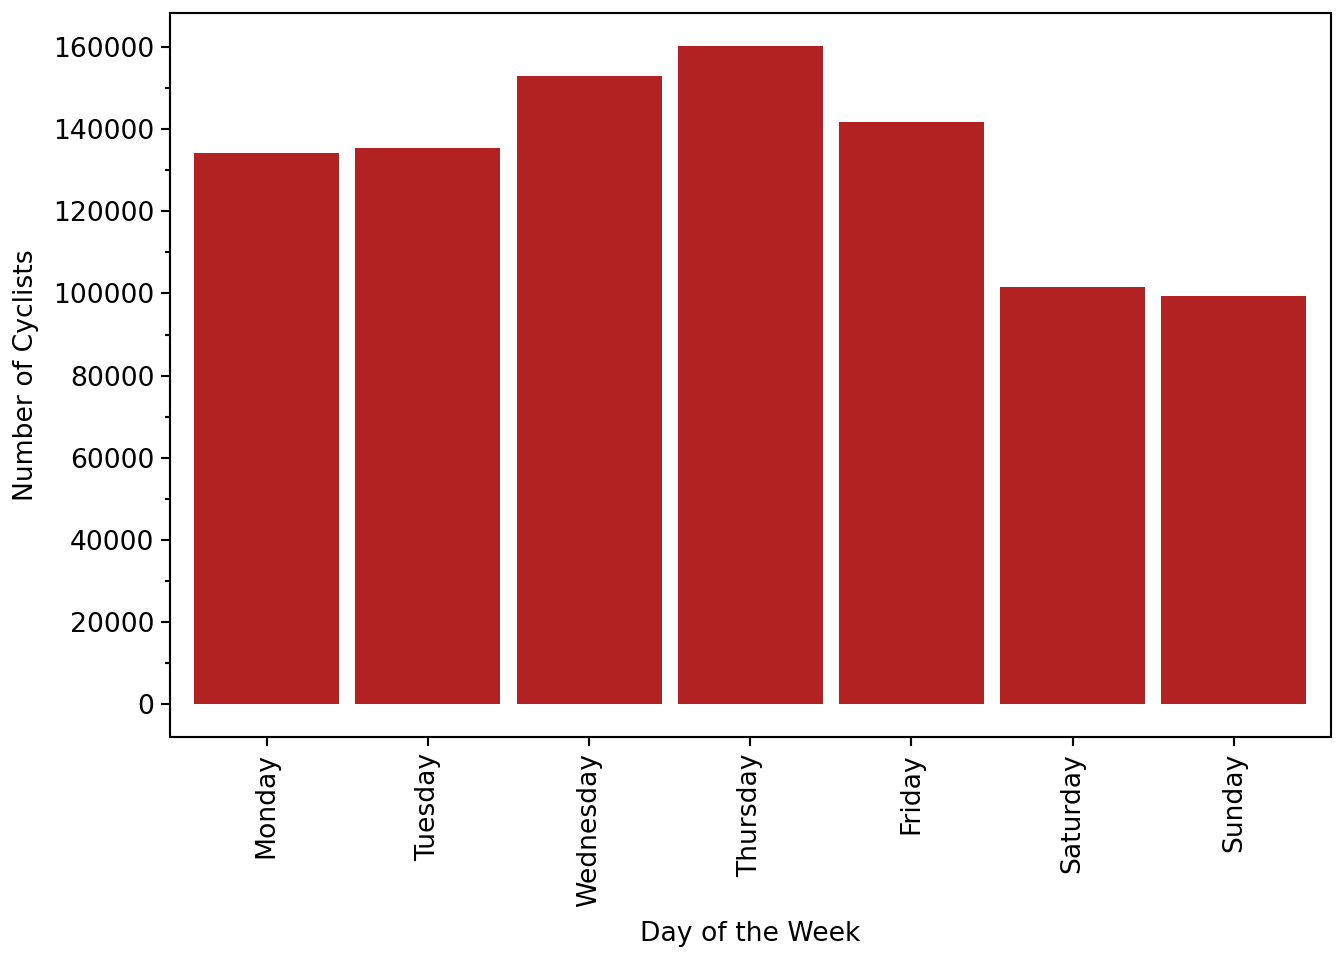

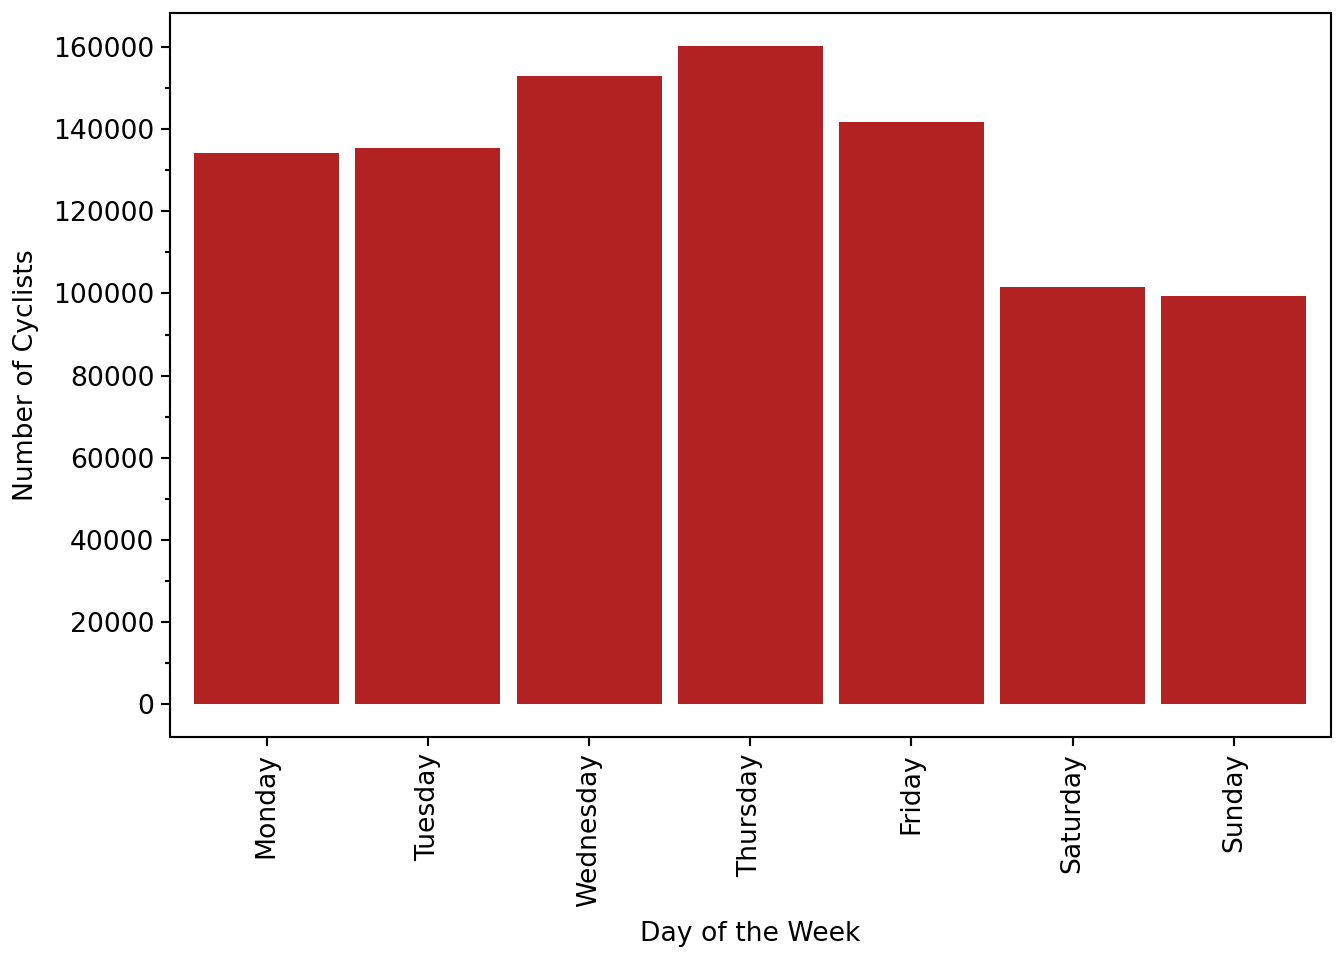

In [15]:
weekday_counts = (
    berri_bikes
    .group_by('weekday')
    .aggregate(cyclist_count = _['Berri 1'].sum()) #I'm using the square bracket colref instead of the dot notation, so that I can quote the colname to deal with the space in the column name
    .mutate(
        weekday_name = _.weekday.cases(
            (0, 'Monday'),
            (1, 'Tuesday'),
            (2, 'Wednesday'),
            (3, 'Thursday'),
            (4, 'Friday'),
            (5, 'Saturday'),
            (6, 'Sunday')
        )
    )
    .order_by('weekday')
)

print(weekday_counts)

(   p9.ggplot(weekday_counts, p9.aes(x="reorder(weekday_name, weekday, ascending=True)", y="cyclist_count")) +
    p9.geom_col(fill='firebrick') +
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits)) +
    p9.labs(x="Day of the Week", y="Number of Cyclists") +
    p9.theme_matplotlib() +
    p9.theme(axis_text_x=p9.element_text(angle=90))
)

# Original Pandas Tutorial Code:
# weekday_counts = berri_bikes.groupby('weekday').sum()
# weekday_counts.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# weekday_counts.plot(kind='bar')

## Chapter 6 - String Operations- Which month was the snowiest

Yes, we skipped Chapter 5 of the tutorial. That was all about downloading individual CSV files from a web page, and then importing them and joining them together into single dataframe. The original CSV files aren't available any more, so let's pickup the tutorial at Chapter 6, which is about working with that unified data.

In [16]:
weather_2012 = con.read_csv('./data/weather_2012.csv.zst')

weather_2012

# (   p9.ggplot(weekday_counts, p9.aes(x="reorder(weekday_name, weekday, ascending=True)", y="cyclist_count")) + \
#     p9.geom_col(fill='firebrick') + \
#     p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits)) + \
#     p9.labs(x="Day of the Week", y="Number of Cyclists") + \
#     p9.theme_matplotlib() + \
#     p9.theme(axis_text_x=p9.element_text(angle=90))
# )

# Original Pandas Tutorial Code:
# weather_2012_final = pd.read_csv('./data/weather_2012.csv', index_col='Date/Time')
# weather_2012_final['Temp (C)'].plot(figsize=(15, 6))

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Date/Time           ┃ Temp (C) ┃ Dew Point Temp (C) ┃ Rel Hum (%) ┃ Wind Spd (km/h) ┃ Visibility (km) ┃ Stn Press (kPa) ┃ Weather              ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ timestamp(6)        │ float64  │ float64            │ int64       │ int64           │ float64         │ float64         │ string               │
├─────────────────────┼──────────┼────────────────────┼─────────────┼─────────────────┼─────────────────┼─────────────────┼──────────────────────┤
│ 2012-01-01 00:00:00 │     -1.8 │               -3.9 │          86 │               4 │             8.0 │          101.24 │ Fog                  │
│ 2012-01-01 01:00:00 │     -1.8 │               -3.7 │          87 │               4 │             8.0 │          101.24 │ Fog                  │
│ 2012-01-01 02:00:00 │     -1.8 │               -3.4 │          89 │               7 │             4.0 │          101.26 │ Freezing Drizzle,Fog │
│ 2012-01-01 03:00:00 │     -1.5 │               -3.2 │          88 │               6 │             4.0 │          101.27 │ Freezing Drizzle,Fog │
│ 2012-01-01 04:00:00 │     -1.5 │               -3.3 │          88 │               7 │             4.8 │          101.23 │ Fog                  │
│ 2012-01-01 05:00:00 │     -1.4 │               -3.3 │          87 │               9 │             6.4 │          101.27 │ Fog                  │
│ 2012-01-01 06:00:00 │     -1.5 │               -3.1 │          89 │               7 │             6.4 │          101.29 │ Fog                  │
│ 2012-01-01 07:00:00 │     -1.4 │               -3.6 │          85 │               7 │             8.0 │          101.26 │ Fog                  │
│ 2012-01-01 08:00:00 │     -1.4 │               -3.6 │          85 │               9 │             8.0 │          101.23 │ Fog                  │
│ 2012-01-01 09:00:00 │     -1.3 │               -3.1 │          88 │              15 │             4.0 │          101.20 │ Fog                  │
│ …                   │        … │                  … │           … │               … │               … │               … │ …                    │
└─────────────────────┴──────────┴────────────────────┴─────────────┴─────────────────┴─────────────────┴─────────────────┴──────────────────────┘

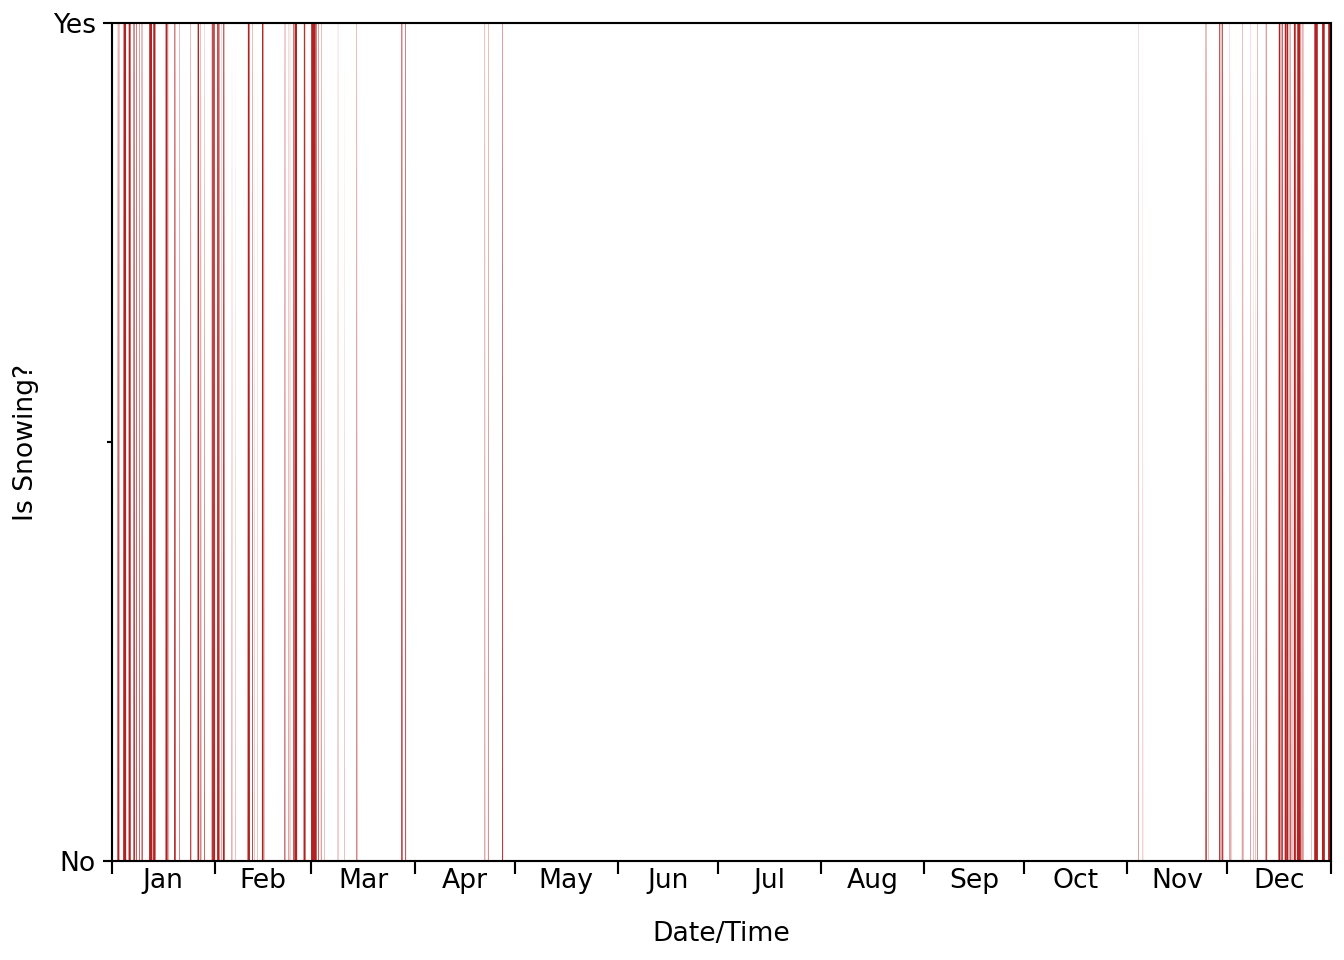

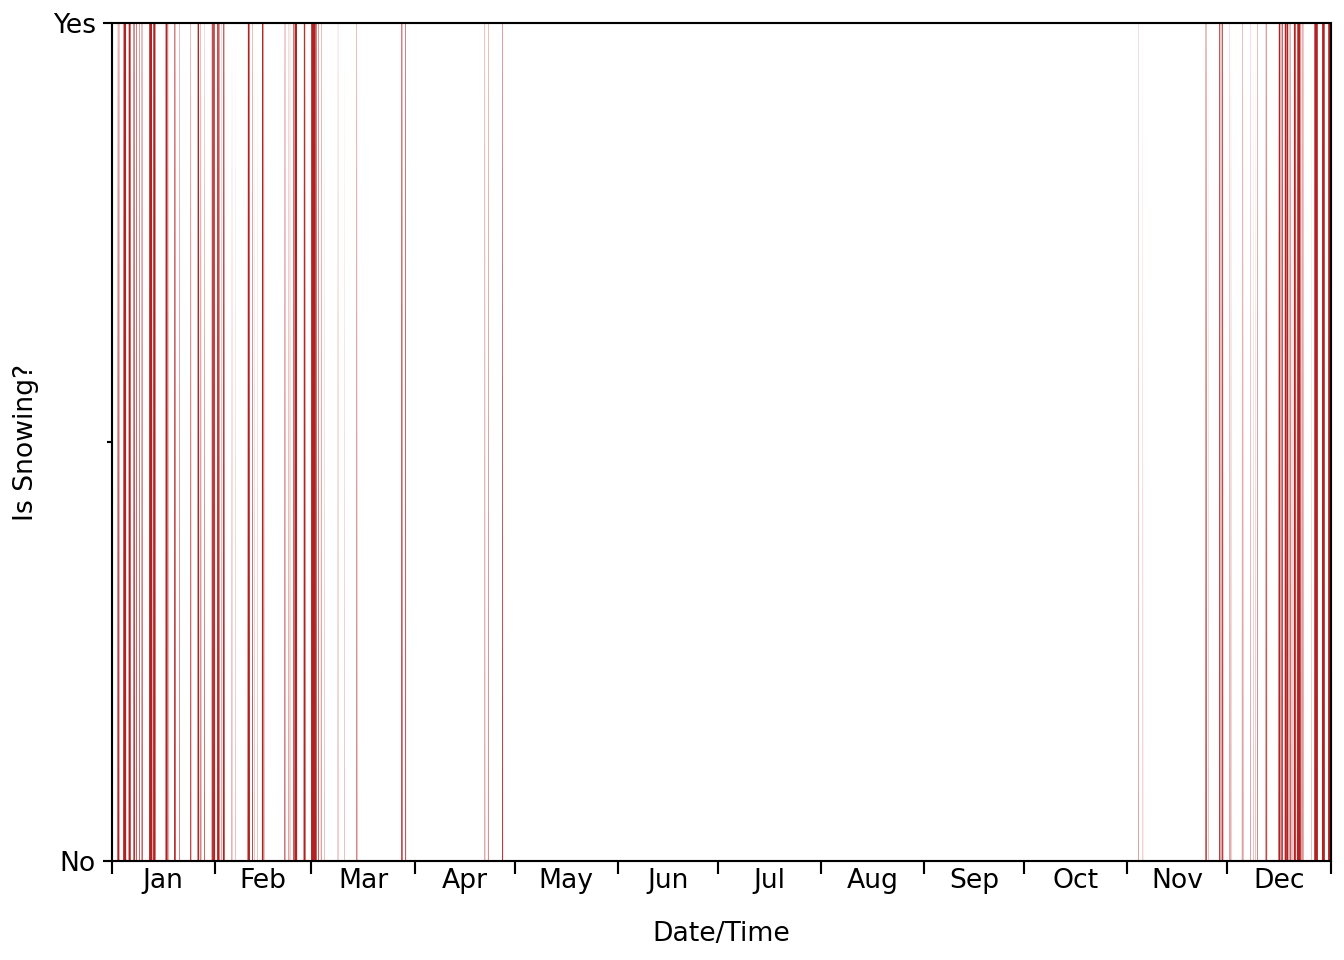

In [17]:
weather_2012 = (
    weather_2012
    .mutate(
        is_snowing = _.Weather.contains('Snow').cast('int64')
    ).mutate(
        month_start = _['Date/Time'].truncate('M'),
        month_end = _['Date/Time'].truncate('M') + ibis.interval(months=1)
    ).mutate(
        midpoint_datetime = _.month_start + (_.month_end - _.month_start) * 0.5
    )
)

weather_2012

# Optional: I wanted to get the month labels on the x-axis lined up exactly over month month midpoints, hence the calculation below:
midpoint_datetime = (
    weather_2012
    .select('midpoint_datetime')
    .distinct()
    .order_by('midpoint_datetime')
    .midpoint_datetime
    .to_pyarrow()
    .to_pylist()
)

(   p9.ggplot(weather_2012, p9.aes(x="Date/Time", y="is_snowing")) +
    p9.geom_area(fill='firebrick') +
    p9.scale_y_continuous(breaks=[0, 1], labels=['No', 'Yes'], expand=(0, 0, 0, 0)) +
    p9.scale_x_datetime(breaks=midpoint_datetime, date_minor_breaks='1 month', date_labels='%b', expand=(0, 0, 0, 0)) +
    p9.labs(x="Date/Time", y="Is Snowing?") +
    p9.theme_matplotlib() +
    p9.theme(
        axis_ticks_length_major_x=0,
        axis_ticks_length_minor_x=5
    ) 
)

# Original Pandas Tutorial Code:
# weather_description = weather_2012['Weather']
# is_snowing = weather_description.str.contains('Snow')
# is_snowing=is_snowing.astype(float)
# is_snowing.plot()

Finding the snowiest month:

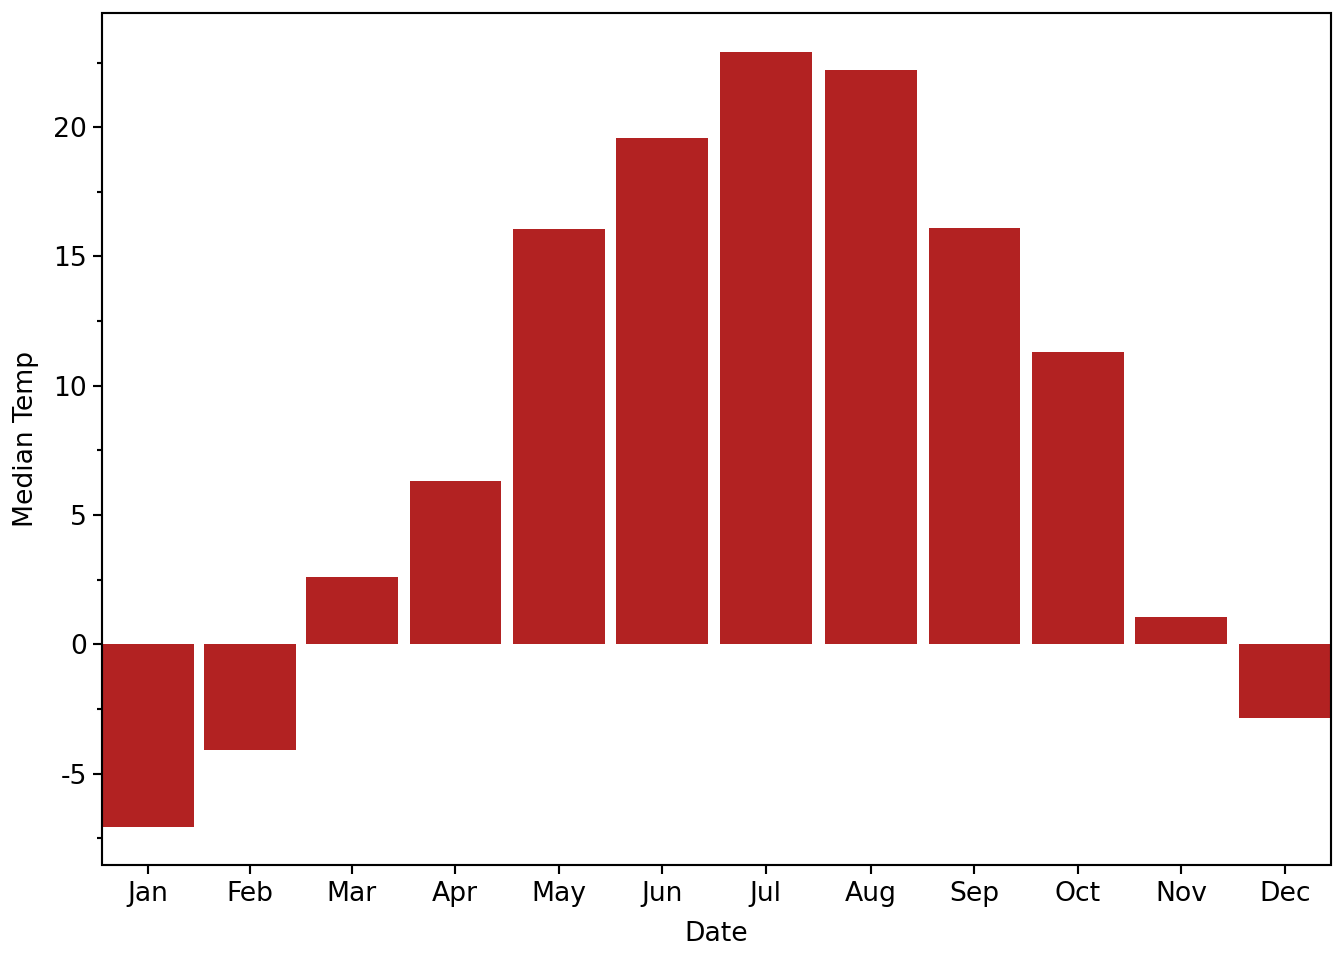

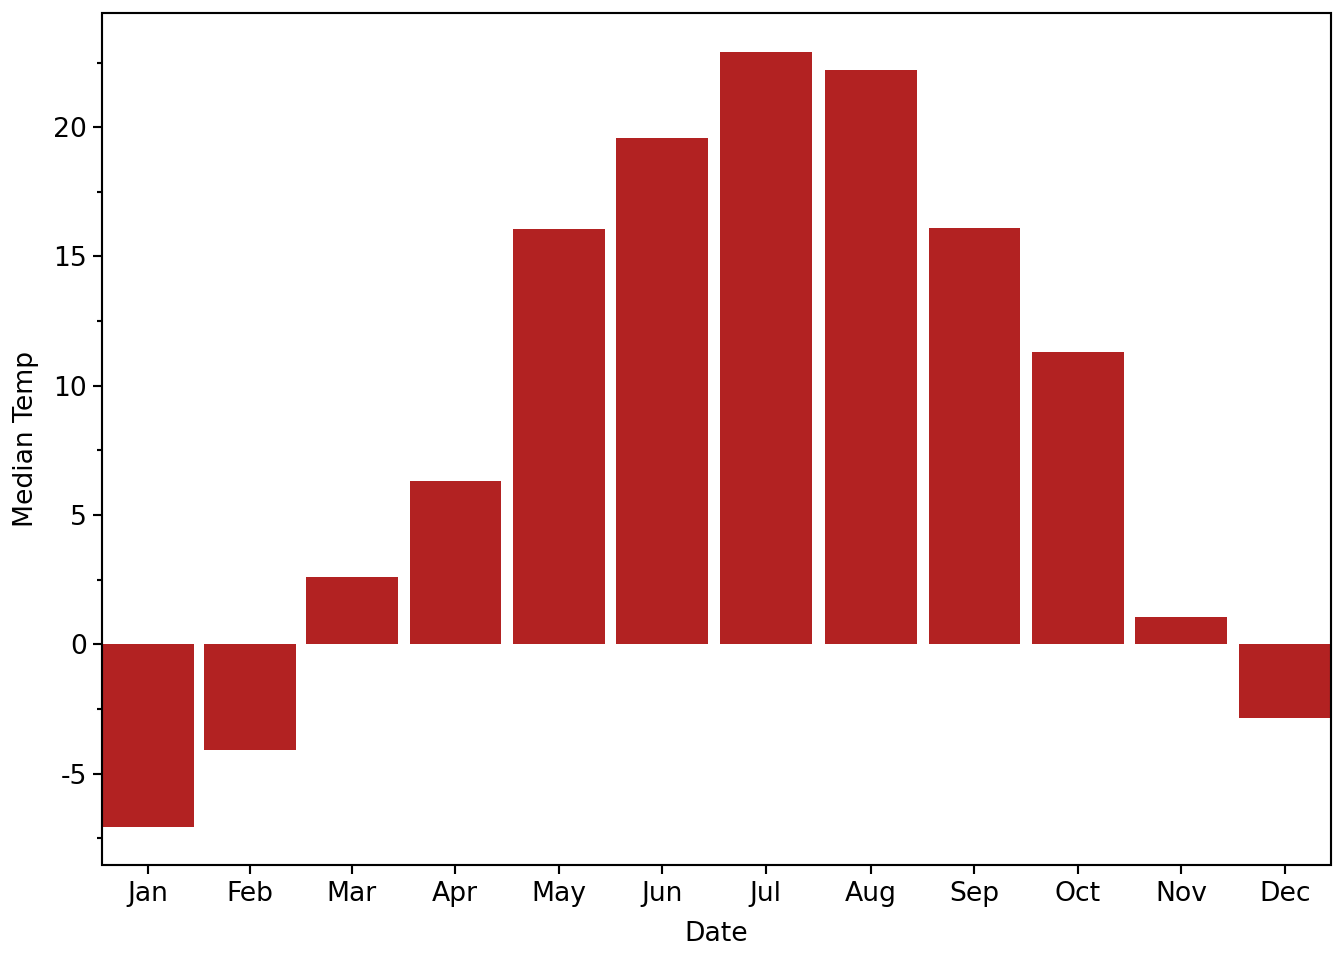

In [18]:
median_temps = (
    weather_2012
    .group_by('month_start', 'month_end', 'midpoint_datetime')
    .aggregate(
        median_temp = _['Temp (C)'].median()
    )
)

month_midpoints = median_temps.midpoint_datetime.to_pyarrow().to_pylist()

(   p9.ggplot(median_temps, p9.aes(x="midpoint_datetime", y="median_temp")) +
    p9.geom_col(fill='firebrick') +
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=8).tick_values(*limits)) +
    p9.scale_x_datetime(breaks=month_midpoints, minor_breaks=None, date_labels='%b', expand=(0, 0, 0, 0)) +
    p9.labs(x="Date", y="Median Temp") +
    p9.theme_matplotlib()
)

# Original Pandas Tutorial Code:
# weather_2012['Temp (C)'].resample('M').apply(np.median).plot(kind='bar')

 Find the percentage of time it was snowing each month:

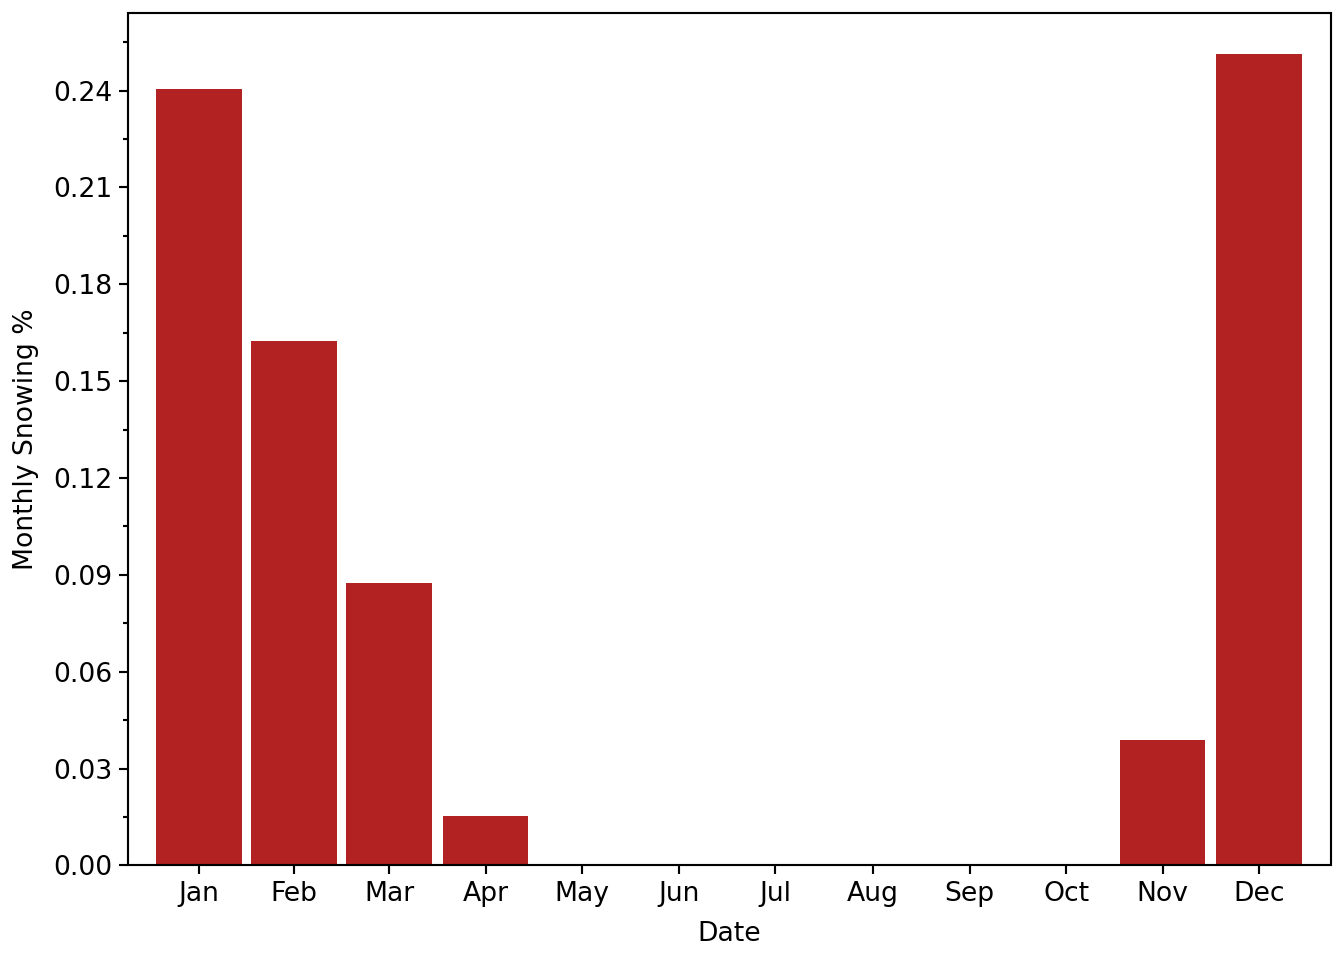

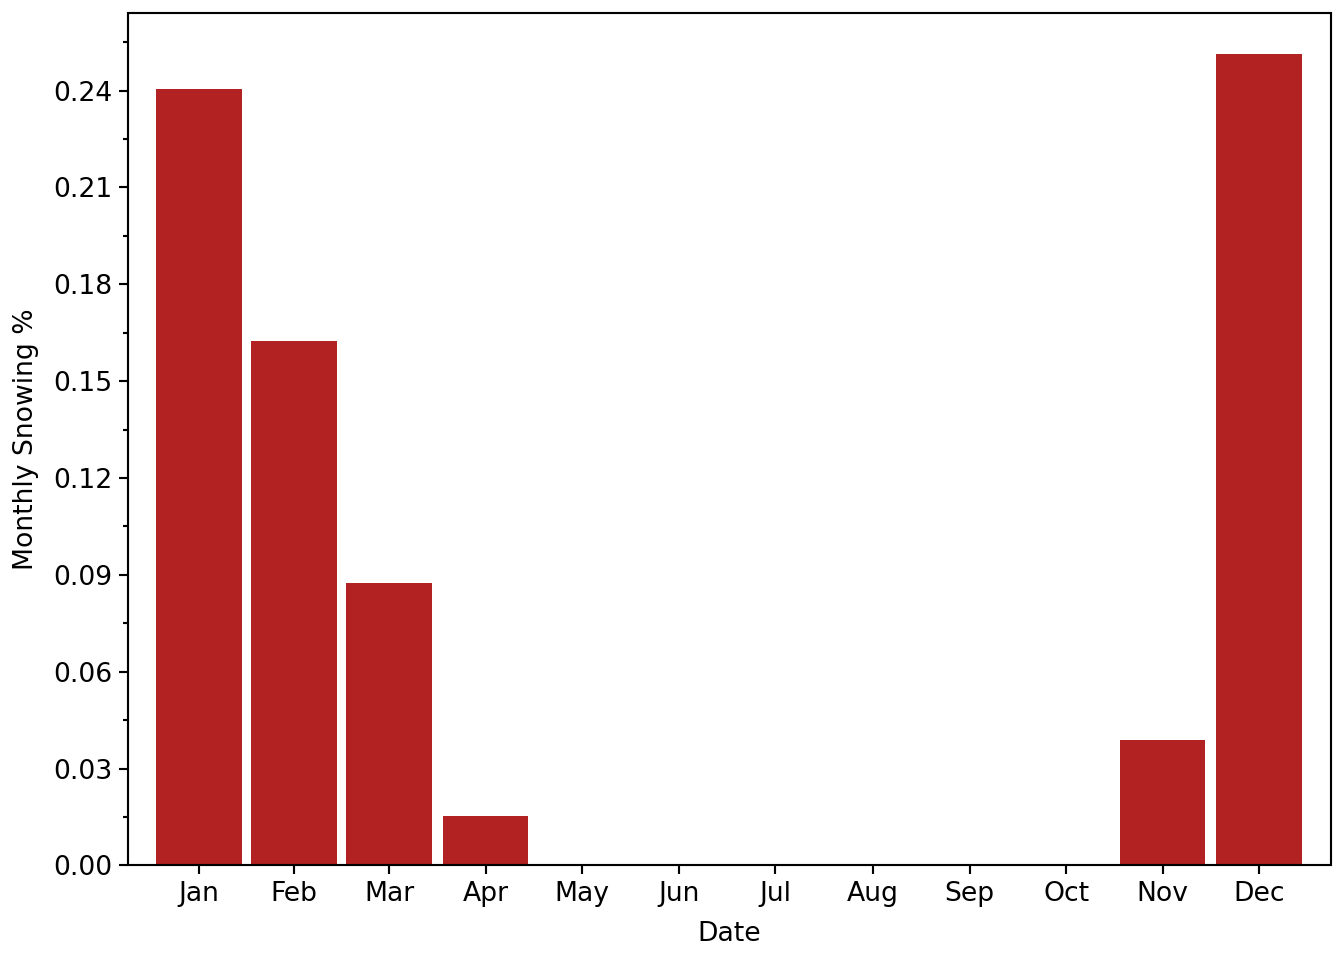

In [19]:
monthly_snow_percentage = (
    weather_2012
    .group_by('month_start', 'month_end', 'midpoint_datetime')
    .aggregate(
        snow_percentage = _.is_snowing.mean()
    )
)

monthly_snow_percentage

(   p9.ggplot(monthly_snow_percentage, p9.aes(x="midpoint_datetime", y="snow_percentage")) +
    p9.geom_col(fill='firebrick') +
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits), expand=(0, 0, 0.05, 0)) +
    p9.scale_x_datetime(breaks=month_midpoints, minor_breaks=None, date_labels='%b', expand=(0.025, 0, 0.025, 0)) +
    p9.labs(x="Date", y="Monthly Snowing %") +
    p9.theme_matplotlib()
)

# Original Pandas Tutorial Code:
# weather_description = weather_2012['Weather']
# is_snowing = weather_description.str.contains('Snow')
# is_snowing.astype(float).resample('M').apply(np.mean).plot(kind='bar')

Creating a single dataframe with temperatures and snow percentages, and then plotting both:

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ month_start         ┃ month_end           ┃ midpoint_datetime   ┃ median_temp ┃ snow_percentage ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ timestamp           │ timestamp           │ timestamp           │ float64     │ float64         │
├─────────────────────┼─────────────────────┼─────────────────────┼─────────────┼─────────────────┤
│ 2012-12-01 00:00:00 │ 2013-01-01 00:00:00 │ 2012-12-16 12:00:00 │       -2.85 │        0.251344 │
│ 2012-08-01 00:00:00 │ 2012-09-01 00:00:00 │ 2012-08-16 12:00:00 │       22.20 │        0.000000 │
│ 2012-03-01 00:00:00 │ 2012-04-01 00:00:00 │ 2012-03-16 12:00:00 │        2.60 │        0.087366 │
│ 2012-06-01 00:00:00 │ 2012-07-01 00:00:00 │ 2012-06-16 00:00:00 │       19.60 │        0.000000 │
│ 2012-01-01 00:00:00 │ 2012-02-01 00:00:00 │ 2012-01-16 12:00:00 │       -7.05 │        0.240591 │


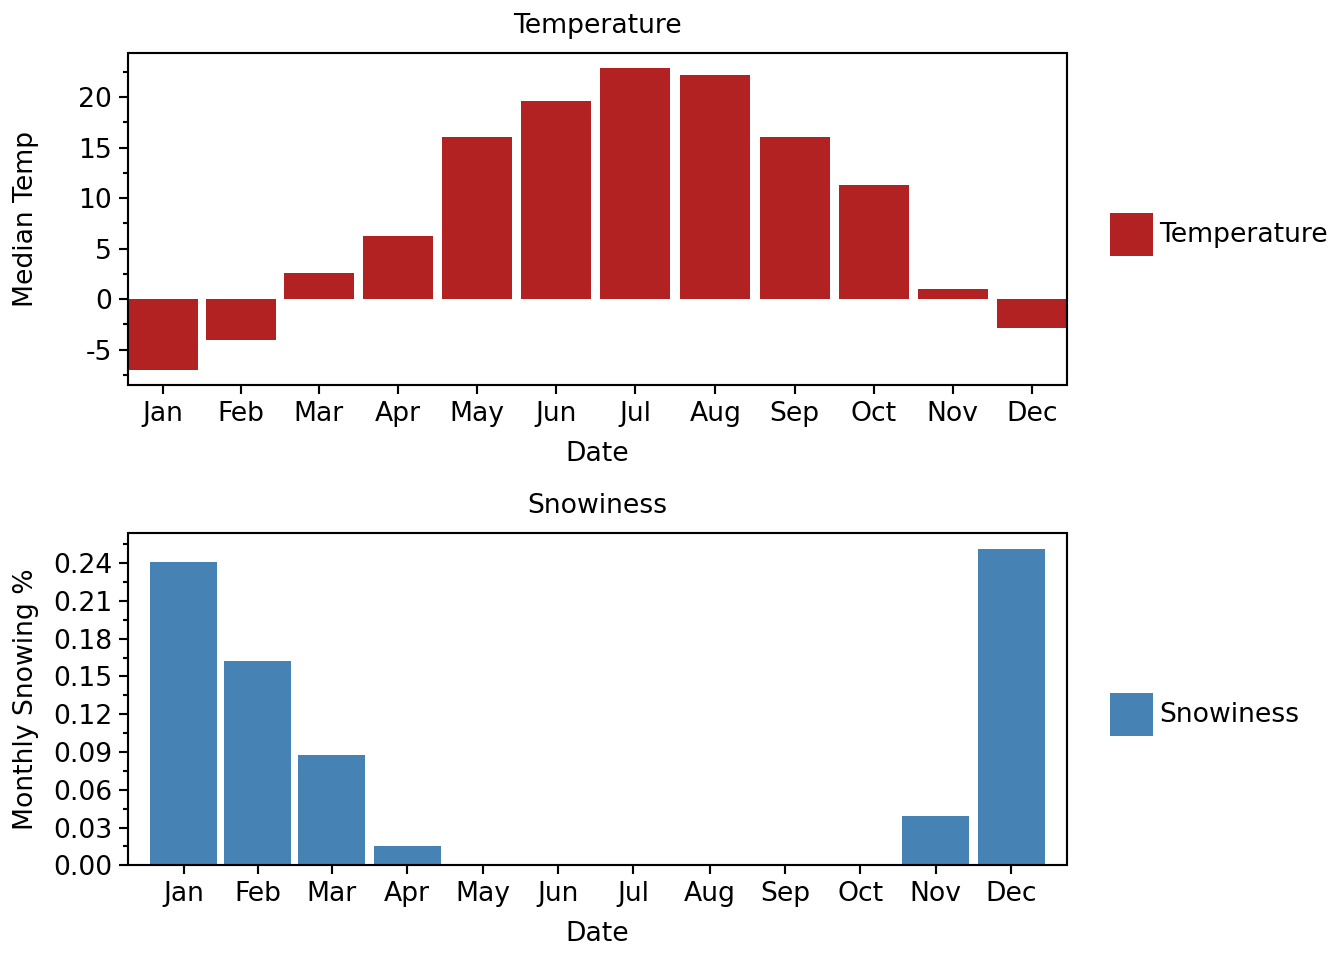

In [20]:
median_temps_and_snow_perc = (
    weather_2012
    .group_by('month_start', 'month_end', 'midpoint_datetime')
    .aggregate(
        median_temp = _['Temp (C)'].median(),
        snow_percentage = _.is_snowing.mean()
    )
)

print(median_temps_and_snow_perc)

temp_plot = (
    p9.ggplot(median_temps_and_snow_perc, p9.aes(x="midpoint_datetime", y="median_temp", fill='"Temperature"')) +
    p9.geom_col() +
    p9.scale_fill_manual(values=['firebrick']) + 
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=8).tick_values(*limits)) +
    p9.scale_x_datetime(breaks=month_midpoints, minor_breaks=None, date_labels='%b', expand=(0, 0, 0, 0)) +
    p9.labs(x="Date", y="Median Temp", title="Temperature", fill="") +
    p9.theme_matplotlib()
)

snow_plot = (
    p9.ggplot(median_temps_and_snow_perc, p9.aes(x="midpoint_datetime", y="snow_percentage", fill='"Snowiness"')) +
    p9.geom_col() +
    p9.scale_fill_manual(values=['steelblue']) + 
    p9.scale_y_continuous(breaks=lambda limits: MaxNLocator(nbins=10).tick_values(*limits), expand=(0, 0, 0.05, 0)) +
    p9.scale_x_datetime(breaks=month_midpoints, minor_breaks=None, date_labels='%b', expand=(0.025, 0, 0.025, 0)) +
    p9.labs(x="Date", y="Monthly Snowing %", title="Snowiness", fill="") +
    p9.theme_matplotlib()
)

combined_plot = temp_plot / snow_plot #Plotnine supports the '/' operator to stack plots vertically, and the '|' operator to arrange them side-by-side. 

combined_plot.show()

# Original Pandas Tutorial Code:
# temperature = weather_2012['Temp (C)'].resample('M').apply(np.median)
# is_snowing = weather_2012['Weather'].str.contains('Snow')
# snowiness = is_snowing.astype(float).resample('M').apply(np.mean)
# temperature.name = "Temperature"
# snowiness.name = "Snowiness"
# stats = pd.concat([temperature, snowiness], axis=1)
# stats.plot(kind='bar', subplots=True, figsize=(15, 10))

## Chapter 7 - Cleaning up messy data

In [21]:
requests = complaints

1. Look at the unique list of Zip codes:

Identified bad codes: 'NO CLUE' 'N/A', 'NA' (and apparently '0')

In [22]:
requests.select('Incident_Zip').distinct().order_by('Incident_Zip').to_pyarrow()['Incident_Zip'].to_pylist()

['00000',
 '000000',
 '00083',
 '02061',
 '06901',
 '07020',
 '07087',
 '07093',
 '07109',
 '07114',
 '07201',
 '07208',
 '07306',
 '07604',
 '08807',
 '10000',
 '10001',
 '10002',
 '10003',
 '10004',
 '10005',
 '10006',
 '10007',
 '10009',
 '10010',
 '10011',
 '10012',
 '10013',
 '10014',
 '10016',
 '10017',
 '10018',
 '10019',
 '10020',
 '10021',
 '10022',
 '10023',
 '10024',
 '10025',
 '10026',
 '10027',
 '10028',
 '10029',
 '10030',
 '10031',
 '10032',
 '10033',
 '10034',
 '10035',
 '10036',
 '10037',
 '10038',
 '10039',
 '10040',
 '10044',
 '10048',
 '10065',
 '10069',
 '10075',
 '10103',
 '10107',
 '10112',
 '10119',
 '10128',
 '10129',
 '10153',
 '10162',
 '10280',
 '10281',
 '10282',
 '10301',
 '10302',
 '10303',
 '10304',
 '10305',
 '10306',
 '10307',
 '10308',
 '10309',
 '10310',
 '10312',
 '10314',
 '10451',
 '10452',
 '10453',
 '10454',
 '10455',
 '10456',
 '10457',
 '10458',
 '10459',
 '10460',
 '10461',
 '10462',
 '10463',
 '10464',
 '10465',
 '10466',
 '10467',
 '10468',

2. Inspect the Incident_Zip column for instances of a dash:

In [23]:
requests.filter(_.Incident_Zip.contains('-'))

# Original Pandas Tutorial Code:
# rows_with_dashes = requests['Incident Zip'].str.contains('-').fillna(False)
# requests[rows_with_dashes]

┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Unique_Key ┃ Created_Date        ┃ Closed_Date         ┃ Agency ┃ Agency_Name                    ┃ Complaint_Type     ┃ Descriptor        ┃ Location_Type ┃ Incident_Zip ┃ Incident_Address       ┃ Street_Name        ┃ Cross_Street_1 ┃ Cross_Street_2 ┃ Intersection_Street_1 ┃ Intersection_Street_2 ┃ Address_Type ┃ City       ┃ Landmark ┃ Facility_Type ┃ Status   ┃ Due_Date            ┃ Resolution_Action_Updated_Date ┃ Community_Board ┃ Borough     ┃ X_Coordinate_(State_Plane) ┃ Y_Coordinate_(State_Plane) ┃ Park_Facility_Name ┃ Park_Borough ┃ School_Name ┃ School_Number ┃ School_Region ┃ School_Code ┃ School_Phone_Number ┃ School_Address ┃ School_City ┃ School_State ┃ School_Zip  ┃ School_Not_Found ┃ School_or_Citywide_Complaint ┃ Vehicle_Type ┃ Taxi_Company_Borough ┃ Taxi_Pick_Up_Location ┃ Bridge_Highway_Name ┃ Bridge_Highway_Direction ┃ Road_Ramp ┃ Bridge_Highway_Segment ┃ Garage_Lot_Name ┃ Ferry_Direction ┃ Ferry_Terminal_Name ┃ Latitude ┃ Longitude ┃ Location ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ int64      │ timestamp(6)        │ timestamp(6)        │ string │ string                         │ string             │ string            │ string        │ string       │ string                 │ string             │ string         │ string         │ string                │ string                │ string       │ string     │ string   │ string        │ string   │ timestamp(6)        │ timestamp(6)                   │ string          │ string      │ int64                      │ int64                      │ string             │ string       │ string      │ string        │ string        │ string      │ string              │ string         │ string      │ string       │ string      │ string           │ string                       │ string       │ string               │ string                │ string              │ string                   │ string    │ string                 │ string          │ string          │ string              │ float64  │ float64   │ string   │
├────────────┼─────────────────────┼─────────────────────┼────────┼─────────────

3. Inspect the instances where the Incident_Zip column is longer than 5 characters:

In [24]:
requests.filter(_.Incident_Zip.length() > 5).Incident_Zip.collect().unique().execute()

# Original Pandas Tutorial Code:
# long_zip_codes = requests['Incident Zip'].str.len() > 5
# requests['Incident Zip'][long_zip_codes].unique()

['29616-0759',
 '11549-3650',
 '35209-3114',
 '000000',
 'NO CLUE',
 '55164-0737',
 '77092-2016']

4. Inspect the instances where the Incident_Zip is '00000':

In [25]:
requests.filter(_.Incident_Zip == '00000')

# Original Pandas Tutorial Code:
# requests[requests['Incident Zip'] == '00000']

┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Unique_Key ┃ Created_Date        ┃ Closed_Date  ┃ Agency ┃ Agency_Name                   ┃ Complaint_Type ┃ Descriptor       ┃ Location_Type ┃ Incident_Zip ┃ Incident_Address ┃ Street_Name    ┃ Cross_Street_1 ┃ Cross_Street_2 ┃ Intersection_Street_1 ┃ Intersection_Street_2 ┃ Address_Type ┃ City   ┃ Landmark ┃ Facility_Type ┃ Status   ┃ Due_Date            ┃ Resolution_Action_Updated_Date ┃ Community_Board ┃ Borough     ┃ X_Coordinate_(State_Plane) ┃ Y_Coordinate_(State_Plane) ┃ Park_Facility_Name ┃ Park_Borough ┃ School_Name ┃ School_Number ┃ School_Region ┃ School_Code ┃ School_Phone_Number ┃ School_Address ┃ School_City ┃ School_State ┃ School_Zip  ┃ School_Not_Found ┃ School_or_Citywide_Complaint ┃ Vehicle_Type ┃ Taxi_Company_Borough ┃ Taxi_Pick_Up_Location ┃ Bridge_Highway_Name ┃ Bridge_Highway_Direction ┃ Road_Ramp ┃ Bridge_Highway_Segment ┃ Garage_Lot_Name ┃ Ferry_Direction ┃ Ferry_Terminal_Name ┃ Latitude ┃ Longitude ┃ Location ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ int64      │ timestamp(6)        │ timestamp(6) │ string │ string                        │ string         │ string           │ string        │ string       │ string           │ string         │ string         │ string         │ string                │ string                │ string       │ string │ string   │ string        │ string   │ timestamp(6)        │ timestamp(6)                   │ string          │ string      │ int64                      │ int64                      │ string             │ string       │ string      │ string        │ string        │ string      │ string              │ string         │ string      │ string       │ string      │ string           │ string                       │ string       │ string               │ string                │ string              │ string                   │ string    │ string                 │ string          │ string          │ string              │ float64  │ float64   │ string   │
├────────────┼─────────────────────┼──────────────┼────────┼───────────────────────────────┼────────────────┼──────────────────┼───────────────┼──────────────┼──────────────────┼──────────

5. Looking at complaints that don't begin with 0 or 1, and therefore might be far away:

In [26]:
ibis.options.repr.interactive.max_rows = 50

(   requests
    .filter(~(_.Incident_Zip.startswith('0') | _.Incident_Zip.startswith('1')))
    .select('Incident_Zip', 'Descriptor', 'City')
    .order_by('Incident_Zip')
)

# Original Pandas Tutorial Code:
# zips = requests['Incident Zip']
# is_close = zips.str.startswith('0') | zips.str.startswith('1')
# is_far = ~(is_close) & zips.notnull()
# zips[is_far]
# requests[is_far][['Incident Zip', 'Descriptor', 'City']].sort_values('Incident Zip')

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Incident_Zip ┃ Descriptor                  ┃ City         ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ string       │ string                      │ string       │
├──────────────┼─────────────────────────────┼──────────────┤
│ 23502        │ Harassment                  │ NORFOLK      │
│ 23541        │ Harassment                  │ NORFOLK      │
│ 29616-0759   │ Debt Not Owed               │ GREENVILLE   │
│ 35209-3114   │ Harassment                  │ BIRMINGHAM   │
│ 41042        │ Harassment                  │ FLORENCE     │
│ 55164-0737   │ Harassment                  │ ST. PAUL     │
│ 61702        │ Billing Dispute             │ BLOOMIGTON   │
│ 70711        │ Contract Dispute            │ CLIFTON      │
│ 77056        │ Debt Not Owed               │ HOUSTON      │
│ 77092-2016   │ False Advertising           │ HOUSTON      │
│ 90010        │ Billing Dispute             │ LOS ANGELES  │
│ 92123        │ Billing Dispute             │ SAN DIEGO    │
│ 92123        │ Harassment                  │ SAN DIEGO    │
│ N/A          │ House/Property Damaged      │ N/A          │
│ N/A          │ Driver Complaint            │ N/A          │
│ N/A          │ Non-Delivery Goods/Services │ N/A          │
│ N/A          │ Harassment                  │ N/A          │
│ N/A          │ Driver Complaint            │ N/A          │
│ N/A          │ Non-Delivery Goods/Services │ N/A          │
│ NA           │ Driver Complaint            │ NA           │
│ NO CLUE      │ Driver Complaint            │ NORTH BERGEN │
└──────────────┴─────────────────────────────┴──────────────┘

6. Look at volume of complaints by City:

In [27]:
ibis.options.repr.interactive.max_rows = 10

(   requests
    .mutate(City = _.City.upper())
    .group_by('City')
    .aggregate(n=_.count())
    .order_by(ibis.desc('n'))
)

# Original Pandas Tutorial Code:
# requests['City'].str.upper().value_counts()

┏━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ City          ┃ n     ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━┩
│ string        │ int64 │
├───────────────┼───────┤
│ BROOKLYN      │ 31662 │
│ NEW YORK      │ 22664 │
│ BRONX         │ 18438 │
│ NULL          │ 12208 │
│ STATEN ISLAND │  4766 │
│ JAMAICA       │  2246 │
│ FLUSHING      │  1803 │
│ ASTORIA       │  1568 │
│ RIDGEWOOD     │  1073 │
│ CORONA        │   707 │
│ …             │     … │
└───────────────┴───────┘

Fixing the dataset:

In [28]:
requests = (
    requests
    .mutate(
        Incident_Zip = ibis.cases(
            (_.Incident_Zip.isin(['NO CLUE', 'N/A', '0']), ibis.null()),
            (_.Incident_Zip == '00000', ibis.null()),
            (_.Incident_Zip.length() > 5, _.Incident_Zip.substr(0, 5)),
            else_ = _.Incident_Zip
        )
    )
)

# Original Pandas Tutorial Code:
# na_values = ['NO CLUE', 'N/A', '0']
# requests = pd.read_csv('./data/311-service-requests.csv', na_values=na_values, dtype={'Incident Zip': str})
#
# def fix_zip_codes(zips):
#     # Truncate everything to length 5 
#     zips = zips.str.slice(0, 5)
    
#     # Set 00000 zip codes to nan
#     zero_zips = zips == '00000'
#     zips[zero_zips] = np.nan
    
#     return zips
#
# requests['Incident Zip'] = fix_zip_codes(requests['Incident Zip'])

## Chapter 8 - How to deal with timestamps

In [29]:
popcon = (
    con.read_csv(
        './data/popularity-contest.txt.zst',
        sep=' ',
        null_padding=True,
        column_names=['atime', 'ctime', 'package-name', 'mru-program', 'tag']
    )
    .mutate(row_index=ibis.row_number())
    .filter(_.row_index < _.row_index.max())
    .drop('row_index')
)

popcon.head(5)

# Original Pandas Tutorial Code:
# popcon = pd.read_csv('./data/popularity-contest', sep=' ', )[:-1]
# popcon.columns = ['atime', 'ctime', 'package-name', 'mru-program', 'tag']
# popcon[:5]

┏━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ atime      ┃ ctime      ┃ package-name ┃ mru-program                                  ┃ tag            ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ string     │ string     │ string       │ string                                       │ string         │
├────────────┼────────────┼──────────────┼──────────────────────────────────────────────┼────────────────┤
│ 1387295797 │ 1367633260 │ perl-base    │ /usr/bin/perl                                │ NULL           │
│ 1387295796 │ 1354370480 │ login        │ /bin/su                                      │ NULL           │
│ 1387295743 │ 1354341275 │ libtalloc2   │ /usr/lib/x86_64-linux-gnu/libtalloc.so.2.0.7 │ NULL           │
│ 1387295743 │ 1387224204 │ libwbclient0 │ /usr/lib/x86_64-linux-gnu/libwbclient.so.0   │ <RECENT-CTIME> │
│ 1387295742 │ 1354341253 │ libselinux1  │ /lib/x86_64-linux-gnu/libselinux.so.1        │ NULL           │
└────────────┴────────────┴──────────────┴──────────────────────────────────────────────┴────────────────┘

Convert the atime and ctime columns to timestamp data types:

In [30]:
popcon = (
    popcon
    .mutate(
        atime = _.atime.cast('int64').cast('timestamp'),
        ctime = _.ctime.cast('int64').cast('timestamp')
    )
)

popcon.head(5)

# Original Pandas Tutorial Code:
# popcon['atime'] = popcon['atime'].astype(int)
# popcon['ctime'] = popcon['ctime'].astype(int)
# popcon['atime'] = pd.to_datetime(popcon['atime'], unit='s')
# popcon['ctime'] = pd.to_datetime(popcon['ctime'], unit='s')
# popcon[:5]

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ atime               ┃ ctime               ┃ package-name ┃ mru-program                                  ┃ tag            ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ timestamp           │ timestamp           │ string       │ string                                       │ string         │
├─────────────────────┼─────────────────────┼──────────────┼──────────────────────────────────────────────┼────────────────┤
│ 2013-12-17 15:56:37 │ 2013-05-04 02:07:40 │ perl-base    │ /usr/bin/perl                                │ NULL           │
│ 2013-12-17 15:56:36 │ 2012-12-01 14:01:20 │ login        │ /bin/su                                      │ NULL           │
│ 2013-12-17 15:55:43 │ 2012-12-01 05:54:35 │ libtalloc2   │ /usr/lib/x86_64-linux-gnu/libtalloc.so.2.0.7 │ NULL           │
│ 2013-12-17 15:55:43 │ 2013-12-16 20:03:24 │ libwbclient0 │ /usr/lib/x86_64-linux-gnu/libwbclient.so.0   │ <RECENT-CTIME> │
│ 2013-12-17 15:55:42 │ 2012-12-01 05:54:13 │ libselinux1  │ /lib/x86_64-linux-gnu/libselinux.so.1        │ NULL           │
└─────────────────────┴─────────────────────┴──────────────┴──────────────────────────────────────────────┴────────────────┘

Remove all records with a timestamp of 0 i.e. 1970-01-01:

In [31]:
popcon = (
    popcon
    .filter(_.atime > '1970-01-01')
)

# Original Pandas Tutorial Code:
# popcon = popcon[popcon['atime'] > '1970-01-01']

Inspect rows where the package name doesn't include 'lib':

In [32]:
nonlibraries = (
    popcon
    .filter(~(_['package-name'].contains('lib')))
    .order_by(ibis.desc('ctime'))
)

nonlibraries.head(10)

# Original Pandas Tutorial Code:
# nonlibraries = popcon[~popcon['package-name'].str.contains('lib')]
# nonlibraries.sort_values('ctime', ascending=False)[:10]

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ atime               ┃ ctime               ┃ package-name              ┃ mru-program                                                                      ┃ tag            ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ timestamp           │ timestamp           │ string                    │ string                                                                           │ string         │
├─────────────────────┼─────────────────────┼───────────────────────────┼──────────────────────────────────────────────────────────────────────────────────┼────────────────┤
│ 2013-12-17 04:55:39 │ 2013-12-17 04:55:42 │ ddd                       │ /usr/bin/ddd                                                                     │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:05:13 │ nodejs                    │ /usr/bin/npm                                                                     │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:05:04 │ thunderbird-locale-en     │ /usr/lib/thunderbird-addons/extensions/langpack-en-GB@thunderbird.mozilla.org.x… │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:05:04 │ switchboard-plug-keyboard │ /usr/lib/plugs/pantheon/keyboard/options.txt                                     │ <RECENT-CTIME> │
│ 2013-12-16 20:08:27 │ 2013-12-16 20:05:03 │ software-center           │ /usr/sbin/update-software-center                                                 │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:05:00 │ samba-common-bin          │ /usr/bin/net.samba3                                                              │ <RECENT-CTIME> │
│ 2013-12-16 20:08:25 │ 2013-12-16 20:04:59 │ postgresql-client-9.1     │ /usr/lib/postgresql/9.1/bin/psql                                                 │ <RECENT-CTIME> │
│ 2013-12-16 20:08:23 │ 2013-12-16 20:04:58 │ postgresql-9.1            │ /usr/lib/postgresql/9.1/bin/postmaster                                           │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:04:55 │ php5-dev                  │ /usr/include/php5/main/snprintf.h                                                │ <RECENT-CTIME> │
│ 2013-12-16 20:03:20 │ 2013-12-16 20:04:54 │ php-pear                  │ /usr/share/php/XML/Util.php                                                      │ <RECENT-CTIME> │
└─────────────────────┴─────────────────────┴───────────────────────────┴──────────────────────────────────────────────────────────────────────────────────┴────────────────┘

## Chapter 9 - Loading data from SQL databases

And Ibis+DuckDB was doing so well. This section highlights a fairly big limitation: Ibis doesn't have currently have anything as close to the maturity of Panda's read_sql()/to_sql() for getting data into and out of your analysis environment from SQL databases. It's basically upto the backend in question to have ways to import data, and at the moment, DuckDB has fairly limited support. It does however, support SQLite databases, which is exactly the Panda's cookbook tutorial uses to illustrate loaded to and from SQL databases, so let's have a look at the process.

Read from an SQLite database:

In [33]:
# When using Ibis with the DuckDB backend, there is a .read_sqlite() method for that connection.
# This functionality is specific to the DuckDB backend (as it is taking advantage of DuckDB's ability to read from an SQLlite file)
weather_2012_table = con.read_sqlite('./data/weather_2012.sqlite', table_name='weather_2012').head(3)
weather_2012_table

# Original Pandas Tutorial Code:
# con = sqlite3.connect("./data/weather_2012.sqlite")
# df = pd.read_sql("SELECT * from weather_2012 LIMIT 3", con, index_col=['id', 'date_time'])
# df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ id    ┃ date_time           ┃ temp    ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ int64 │ timestamp(6)        │ float64 │
├───────┼─────────────────────┼─────────┤
│     1 │ 2012-01-01 00:00:00 │    -1.8 │
│     2 │ 2012-01-01 01:00:00 │    -1.8 │
│     3 │ 2012-01-01 02:00:00 │    -1.8 │
└───────┴─────────────────────┴─────────┘

Writing to an SQLite database:

In [34]:
shutil.copyfile('./data/weather_2012.sqlite', './data/weather_2012_copy.sqlite')

# Attach the SQLite database file to DuckDB, execute an SQL command to create a table in the attached sqlite from weather_2012 dataframe, then detach the database.
con.attach('./data/weather_2012_copy.sqlite', name='sqlite_db')
con.raw_sql("CREATE TABLE sqlite_db.weather_2012_new AS SELECT * FROM weather_2012")
con.detach('sqlite_db')

# Original Pandas Tutorial Code:
# weather_df = pd.read_csv('./data/weather_2012.csv')
# con = sqlite3.connect("./data/test_db.sqlite")
# con.execute("DROP TABLE IF EXISTS weather_2012")
# weather_df.to_sql("weather_2012", con)

Reading the data back from the SQLite database:

In [35]:
weather_2012_new_from_copy = con.read_sqlite('./data/weather_2012_copy.sqlite', table_name='weather_2012_new').head(3)
print(weather_2012_new_from_copy)

from pathlib import Path
Path('./data/weather_2012_copy.sqlite').unlink()

# Original Pandas Tutorial Code:
# con = sqlite3.connect("./data/test_db.sqlite")
# df = pd.read_sql("SELECT * from weather_2012 ORDER BY Weather LIMIT 3", con)
# df

┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ id    ┃ date_time           ┃ temp    ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ int64 │ string              │ float64 │
├───────┼─────────────────────┼─────────┤
│     1 │ 2012-01-01 00:00:00 │    -1.8 │
│     2 │ 2012-01-01 01:00:00 │    -1.8 │
│     3 │ 2012-01-01 02:00:00 │    -1.8 │
└───────┴─────────────────────┴─────────┘
